In [1]:
import pandas as pd

data = pd.read_csv("StudentsPerformance.csv")

print(data.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [2]:
data = data.rename(columns={
    "math score": "Math",
    "reading score": "Reading",
    "writing score": "Writing"
})

In [3]:
data["ID"] = range(1, len(data)+1)

print(data.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  Math  Reading  Writing  ID  
0                    none    72       72       74   1  
1               completed    69       90       88   2  
2                    none    90       95       93   3  
3                    none    47       57       44   4  
4                    none    76       78       75   5  


In [4]:
attendance = data[["ID"]].copy()

# Random attendance (70–100)
import numpy as np
attendance["Attendance"] = np.random.randint(70, 101, size=len(data))

print(attendance.head())

   ID  Attendance
0   1          71
1   2          70
2   3          96
3   4          93
4   5          99


In [5]:
merged_data = pd.merge(data, attendance, on="ID")

print(merged_data.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  Math  Reading  Writing  ID  Attendance  
0                    none    72       72       74   1          71  
1               completed    69       90       88   2          70  
2                    none    90       95       93   3          96  
3                    none    47       57       44   4          93  
4                    none    76       78       75   5          99  


In [6]:
merged_data["Total"] = merged_data["Math"] + merged_data["Reading"] + merged_data["Writing"]

print(merged_data.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  Math  Reading  Writing  ID  Attendance  Total  
0                    none    72       72       74   1          71    218  
1               completed    69       90       88   2          70    247  
2                    none    90       95       93   3          96    278  
3                    none    47       57       44   4          93    148  
4                    none    76       78       75   5          99    229  


In [7]:
merged_data.to_csv("final_student_data.csv", index=False)

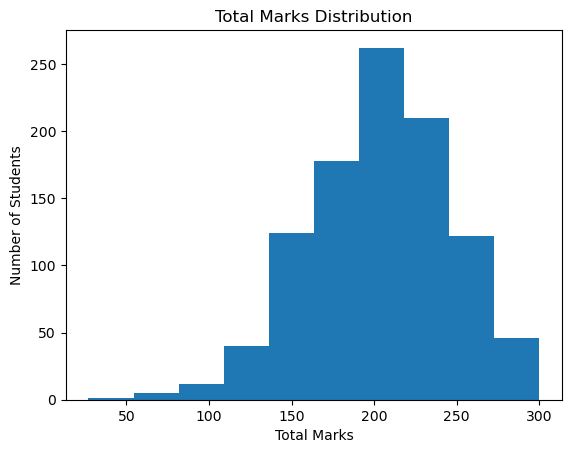

In [8]:
import matplotlib.pyplot as plt

plt.hist(merged_data["Total"])
plt.title("Total Marks Distribution")
plt.xlabel("Total Marks")
plt.ylabel("Number of Students")
plt.show()

In [9]:
# Step 4: Create ID Column
data["ID"] = range(1, len(data)+1)

# Step 5: Create Second Dataset (Attendance)
attendance = data[["ID"]].copy()
attendance["Attendance"] = np.random.randint(70, 101, size=len(data))

# Step 6: Merge Data
merged_data = pd.merge(data, attendance, on="ID")

# Step 7: Basic Analysis
merged_data["Total"] = merged_data["Math"] + merged_data["Reading"] + merged_data["Writing"]

# Step 8: Save Final Dataset
merged_data.to_csv("final_student_data.csv", index=False)

# Display Result
print(merged_data.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  Math  Reading  Writing  ID  Attendance  Total  
0                    none    72       72       74   1          87    218  
1               completed    69       90       88   2          85    247  
2                    none    90       95       93   3          87    278  
3                    none    47       57       44   4          75    148  
4                    none    76       78       75   5          70    229  


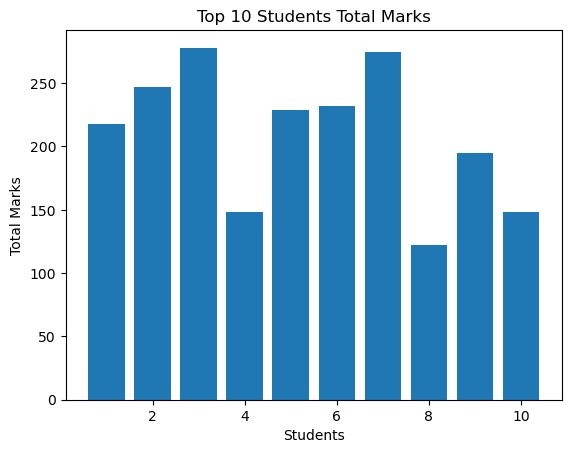

In [11]:
top10 = merged_data.head(10)

plt.figure()
plt.bar(top10["Name"] if "Name" in top10.columns else top10["ID"], top10["Total"])

plt.title("Top 10 Students Total Marks")
plt.xlabel("Students")
plt.ylabel("Total Marks")

plt.show()